In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline
import seaborn as sns
import tensorflow as tf
import sklearn 
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from tensorflow import keras
from keras import metrics
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, GRU, BatchNormalization
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import f1_score, precision_score, recall_score

2024-04-14 16:49:32.377271: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
print("Pandas version: ", pd.__version__)
print("Numpy version: ", np.__version__)
print("Matplotlib version: ", matplotlib.__version__)
print("Seaborn version: ", sns.__version__)
print("Tensorflow version: ", tf.__version__)
print("Scikit-learn version: ", sklearn.__version__)
#print("Keras version: ", keras.__version__)

Pandas version:  2.0.3
Numpy version:  1.23.5
Matplotlib version:  3.7.1
Seaborn version:  0.12.2
Tensorflow version:  2.16.1
Scikit-learn version:  1.3.0


# Loading in Data

In [3]:
go_back = '../data/'
df = pd.read_csv(go_back + 'all_data_train.csv')
df = df.drop(['Unnamed: 0'], axis = 1)
df

,date,team,opponent,score,opponentScore,moneyLine,opponentMoneyLine,total,spread,secondHalfTotal,...,REB/G_opp,AST/G_opp,STL/G_opp,BLK/G_opp,TOV/G_opp,PF/G_opp,PTS/G_opp,win%_opp,home,outcome
0,2008-10-31,Chicago,Boston,80,96,450.0,-600.0,189.0,10.0,94.0,...,36.000000,16.000000,10.000000,0.000000,16.000000,28.000000,90.000000,1.000000,0,0
1,2008-10-31,Boston,Chicago,96,80,-600.0,450.0,189.0,-10.0,94.0,...,40.000000,27.000000,9.000000,6.000000,18.000000,18.000000,108.000000,1.000000,1,1
2,2008-10-31,LA Clippers,Denver,103,113,100.0,-120.0,196.5,1.5,96.5,...,35.000000,17.000000,12.000000,3.000000,13.000000,27.000000,94.000000,0.000000,1,0
3,2008-10-31,Toronto,Golden State,112,108,-280.0,240.0,207.0,-6.5,102.5,...,39.000000,18.000000,10.000000,5.000000,13.000000,26.000000,103.000000,0.000000,1,1
4,2008-10-31,Denver,LA Clippers,113,103,-120.0,100.0,196.5,-1.5,96.5,...,32.000000,24.000000,9.000000,5.000000,18.000000,29.000000,79.000000,0.000000,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22491,2021-04-10,Oklahoma City,Philadelphia,93,117,450.0,-600.0,217.0,10.0,107.0,...,46.057692,23.173077,8.846154,6.230769,14.538462,20.538462,113.653846,0.673077,1,0
22492,2021-04-10,Detroit,Portland,103,118,550.0,-800.0,226.5,11.0,110.5,...,43.843137,20.333333,7.098039,5.176471,10.882353,19.352941,114.980392,0.588235,0,0
22493,2021-04-10,Utah,Sacramento,128,112,-800.0,550.0,229.5,-11.0,113.0,...,42.269231,25.673077,6.711538,4.923077,12.846154,19.519231,114.365385,0.423077,1,1
22494,2021-04-10,Cleveland,Toronto,115,135,-140.0,120.0,218.5,-3.0,106.5,...,41.269231,24.384615,8.461538,5.519231,12.596154,21.961538,111.923077,0.384615,1,0


# Feature Selection

In [4]:
X = df.drop(['team', 'opponent', 'outcome', 'date',
            'score', 'opponentScore', 'total', 'secondHalfTotal'], axis = 1)
Y = df['outcome']

X_train, X_val, y_train, y_val = train_test_split(X, Y, test_size=0.2, random_state=42)

In [5]:
test = pd.read_csv(go_back + 'all_data_test.csv')
X_test = test.drop(['Unnamed: 0', 'team', 'opponent', 'outcome', 'date',
            'score', 'opponentScore', 'total', 'secondHalfTotal'], axis = 1)
y_test = test['outcome']

From prior analysis, reducing the number of features does not improve performance and actually reduces our expected profits.

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

standardized_x = StandardScaler().fit_transform(X)
pca = PCA(n_components=2)
principalComponents = pca.fit_transform(standardized_x)
principalDf = pd.DataFrame(data = principalComponents
             , columns = ['principal component 1', 'principal component 2'])

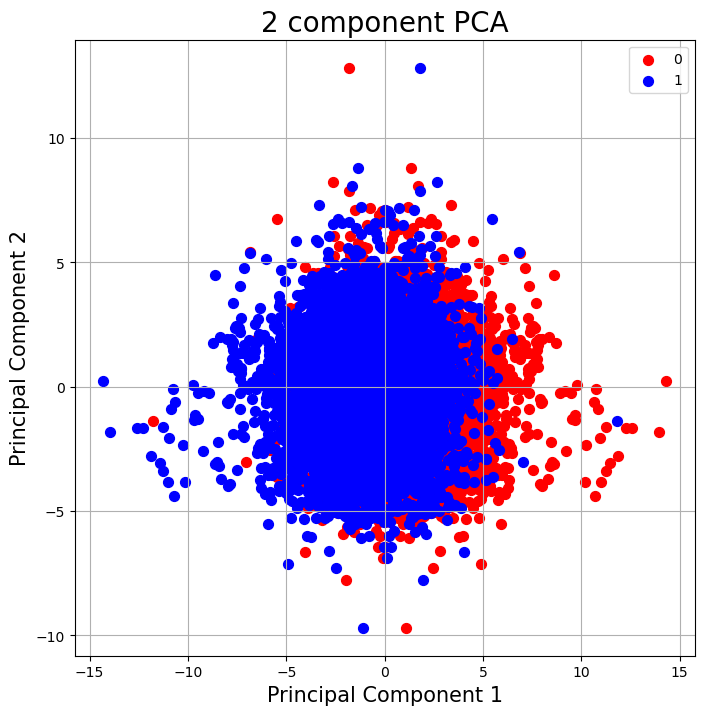

In [7]:
principalDf['target'] = Y

fig = plt.figure(figsize = (8,8))
ax = fig.add_subplot(1,1,1) 
ax.set_xlabel('Principal Component 1', fontsize = 15)
ax.set_ylabel('Principal Component 2', fontsize = 15)
ax.set_title('2 component PCA', fontsize = 20)

targets = [0, 1]
colors = ['r', 'b']
for target, color in zip(targets,colors):
    indicesToKeep = principalDf['target'] == target
    ax.scatter(principalDf.loc[indicesToKeep, 'principal component 1']
               , principalDf.loc[indicesToKeep, 'principal component 2']
               , c = color
               , s = 50)
ax.legend(targets)
ax.grid()

There is not much separability between the two classes based on principal components alone.

# Modeling

In [8]:
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression(fit_intercept= True)
lr_model.fit(X_train, y_train)
lr_train_preds = lr_model.predict(X_train)
lr_val_preds = lr_model.predict(X_val)

train_accuracy = np.mean(lr_train_preds == y_train)
val_accuracy = np.mean(lr_val_preds == y_val)
print(train_accuracy)
print(val_accuracy)

lr_test_preds = lr_model.predict(X_test)
test_accuracy = np.mean(lr_test_preds == y_test)
print(test_accuracy)

0.6852633918648589
0.6808888888888889
0.6784253578732107


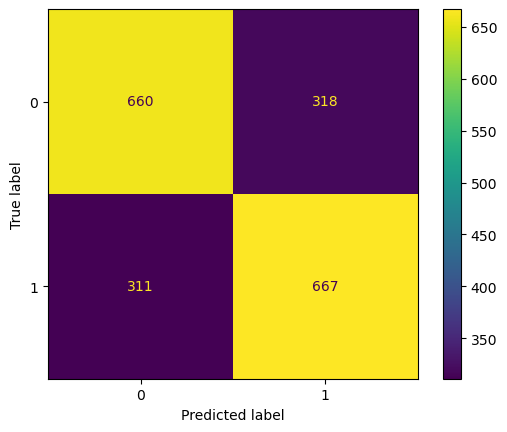

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, lr_test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=lr_model.classes_)
disp.plot()

In [10]:
print(f1_score(y_train, lr_train_preds))
print(f1_score(y_val, lr_val_preds))
print(f1_score(y_test, lr_test_preds))
print(precision_score(y_test, lr_test_preds))
print(recall_score(y_test, lr_test_preds))

0.6856127886323268
0.6777378815080789
0.6795720835455935
0.6771573604060914
0.6820040899795501


In [11]:
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
y_pred = gnb.fit(X_train, y_train)
train_preds = y_pred.predict(X_train)
val_preds = y_pred.predict(X_val)
train_accuracy = np.mean(train_preds == y_train)
val_accuracy = np.mean(val_preds == y_val)
print(train_accuracy)
print(val_accuracy)

gnb_test_preds = gnb.predict(X_test)
test_accuracy = np.mean(gnb_test_preds == y_test)
print(test_accuracy)

0.6810402311624806
0.6782222222222222
0.6615541922290389


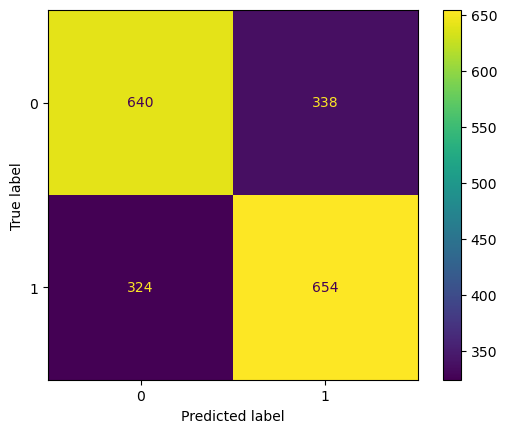

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, gnb_test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=lr_model.classes_)
disp.plot()

In [13]:
print(f1_score(y_train, train_preds))
print(f1_score(y_val, val_preds))
print(f1_score(y_test, gnb_test_preds))
print(precision_score(y_test, gnb_test_preds))
print(recall_score(y_test, gnb_test_preds))

0.681994459833795
0.6767857142857143
0.6639593908629442
0.6592741935483871
0.6687116564417178


In [14]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators = 100,
                                max_depth = 10,
                                min_samples_leaf = 5,
                                random_state = 42)
rf_model.fit(X_train, y_train)

rf_train_preds = rf_model.predict(X_train)
rf_val_preds = rf_model.predict(X_val)

rf_train_accuracy = np.mean(rf_train_preds == y_train)
rf_val_accuracy = np.mean(rf_val_preds == y_val)
print(rf_train_accuracy)
print(rf_val_accuracy)

rf_test_preds = rf_model.predict(X_test)
test_accuracy = np.mean(rf_test_preds == y_test)
print(test_accuracy)

0.774005334518782
0.684
0.6814928425357873


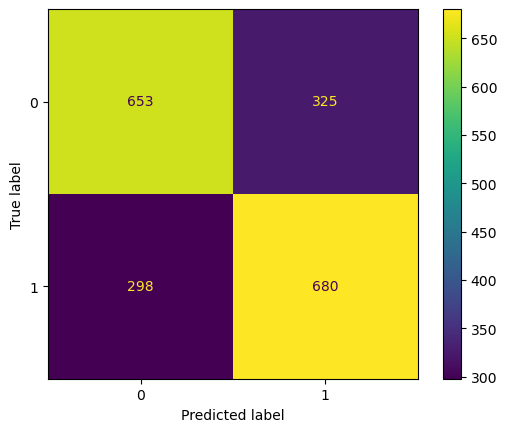

In [15]:
cm = confusion_matrix(y_test, rf_test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=lr_model.classes_)
disp.plot()

In [16]:
print(f1_score(y_train, rf_train_preds))
print(f1_score(y_val, rf_val_preds))
print(f1_score(y_test, rf_test_preds))
print(precision_score(y_test, rf_test_preds))
print(recall_score(y_test, rf_test_preds))

0.7761325480266416
0.6847006651884701
0.6858295511850732
0.6766169154228856
0.6952965235173824


In [17]:
from sklearn import svm
svm_model = svm.SVC()
svm_model.fit(X_train, y_train)

svm_train_preds = svm_model.predict(X_train)
svm_val_preds = svm_model.predict(X_val)

svm_train_accuracy = np.mean(svm_train_preds == y_train)
svm_val_accuracy = np.mean(svm_val_preds == y_val)
print(svm_train_accuracy)
print(svm_val_accuracy)

svm_test_preds = svm_model.predict(X_test)
test_accuracy = np.mean(svm_test_preds == y_test)
print(test_accuracy)

0.6852078239608802
0.682
0.6763803680981595


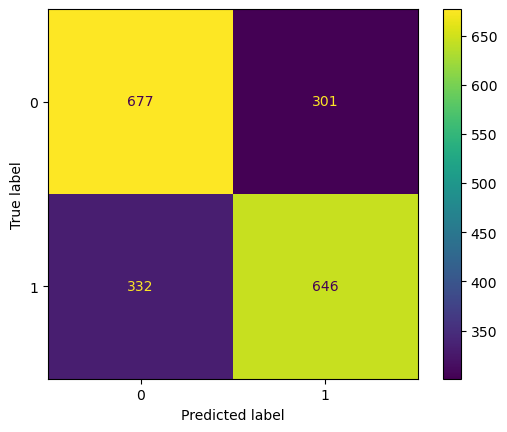

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, svm_test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=lr_model.classes_)
disp.plot()

In [19]:
print(f1_score(y_train, svm_train_preds))
print(f1_score(y_val, svm_val_preds))
print(f1_score(y_test, svm_test_preds))
print(precision_score(y_test, svm_test_preds))
print(recall_score(y_test, svm_test_preds))

0.680899002985411
0.6744027303754268
0.6711688311688312
0.6821541710665259
0.6605316973415133


In [20]:
from sklearn.ensemble import AdaBoostClassifier
ada_model = AdaBoostClassifier(n_estimators=50, learning_rate=0.6)
ada_model.fit(X_train, y_train)

ada_train_preds = ada_model.predict(X_train)
ada_val_preds = ada_model.predict(X_val)

ada_train_accuracy = np.mean(ada_train_preds == y_train)
ada_val_accuracy = np.mean(ada_val_preds == y_val)
print(ada_train_accuracy)
print(ada_val_accuracy)

ada_test_preds = ada_model.predict(X_test)
test_accuracy = np.mean(ada_test_preds == y_test)
print(test_accuracy)

0.6864303178484108
0.6802222222222222
0.6774028629856851


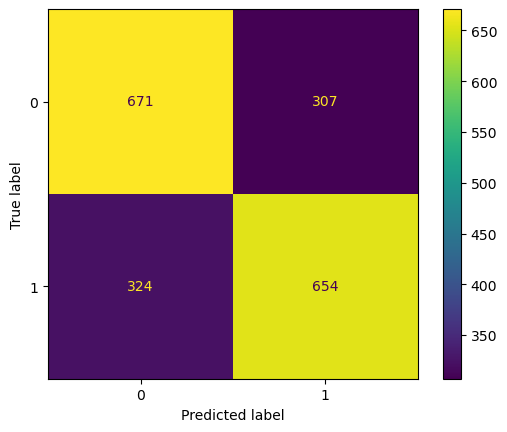

In [21]:
cm = confusion_matrix(y_test, ada_test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=lr_model.classes_)
disp.plot()

In [22]:
print(f1_score(y_train, ada_train_preds))
print(f1_score(y_val, ada_val_preds))
print(f1_score(y_test, ada_test_preds))
print(precision_score(y_test, ada_test_preds))
print(recall_score(y_test, ada_test_preds))

0.6848718378287819
0.6759738797568114
0.6745745229499742
0.6805411030176899
0.6687116564417178


In [23]:
tf.keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

nn_model = keras.Sequential()
nn_model.add(keras.layers.Flatten())
nn_model.add(keras.layers.Dense(units = 1, use_bias = True, activation = "sigmoid"))
optimizer = tf.keras.optimizers.SGD(learning_rate=0.8)
nn_model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=[metrics.binary_accuracy])

nn_model.fit(
        x=X_train,
        y=y_train,
        epochs=20,
        batch_size=500,
        verbose=0)

nn_train_preds = nn_model.predict(X_train).T[0]
nn_val_preds = nn_model.predict(X_val).T[0]

nn_train_accuracy = np.mean(nn_train_preds == y_train)
nn_val_accuracy = np.mean(nn_val_preds == y_val)
print(nn_train_accuracy)
print(nn_val_accuracy)

nn_test_preds = nn_model.predict(X_test).T[0]
test_accuracy = np.mean(nn_test_preds == y_test)
print(test_accuracy)

563/563 ━━━━━━━━━━━━━━━━━━━━ 0s 484us/step
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 490us/step
0.6850966881529229
0.6824444444444444
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 550us/step
0.6758691206543967


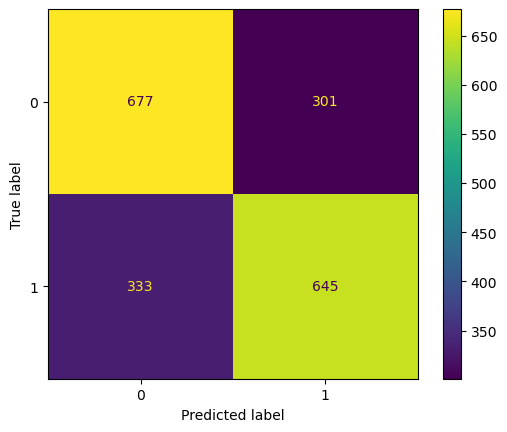

In [24]:
cm = confusion_matrix(y_test.values, nn_test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=lr_model.classes_)
disp.plot()

In [25]:
print(f1_score(y_train, nn_train_preds.astype(int)))
print(f1_score(y_val, nn_val_preds.astype(int)))
print(f1_score(y_test, nn_test_preds.astype(int)))
print(precision_score(y_test, nn_test_preds.astype(int)))
print(recall_score(y_test, nn_test_preds.astype(int)))

0.6806064363410923
0.6745616032794352
0.6704781704781705
0.6818181818181818
0.6595092024539877


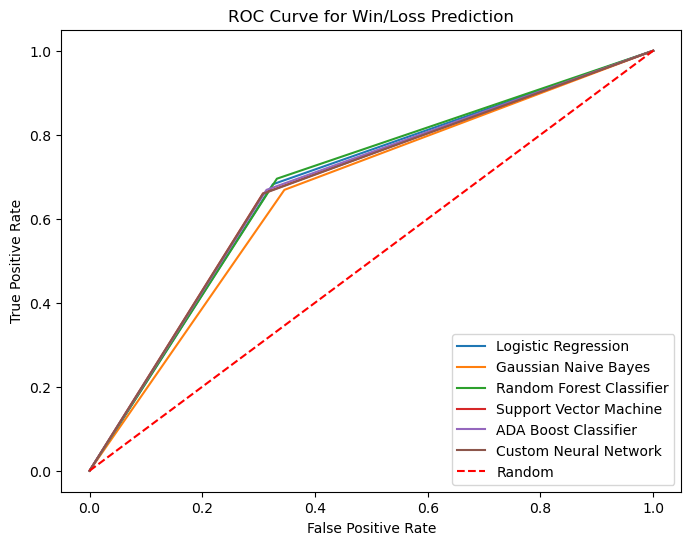

In [26]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc


plt.figure(figsize=(8, 6))

models = [["Logistic Regression", lr_test_preds], ["Gaussian Naive Bayes", gnb_test_preds], 
['Random Forest Classifier', rf_test_preds], ["Support Vector Machine", svm_test_preds ], 
["ADA Boost Classifier", ada_test_preds],["Custom Neural Network", nn_test_preds]]

for name, preds in models:
    fpr, tpr, _ = roc_curve(y_test, preds)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=name)

plt.plot([0, 1], [0, 1], linestyle='--', color='r', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Win/Loss Prediction')
plt.legend()
plt.show()

## Deep Learning Models

In [27]:
dl_df = pd.read_csv(go_back + 'all_data_train.csv')
dl_df = dl_df.drop(['Unnamed: 0','score', 'opponentScore', 'total', 'secondHalfTotal'], axis = 1)
dl_df


,date,team,opponent,moneyLine,opponentMoneyLine,spread,FG%,FG3%,FT%,REB/G,...,REB/G_opp,AST/G_opp,STL/G_opp,BLK/G_opp,TOV/G_opp,PF/G_opp,PTS/G_opp,win%_opp,home,outcome
0,2008-10-31,Chicago,Boston,450.0,-600.0,10.0,0.507246,0.416667,0.750000,40.000000,...,36.000000,16.000000,10.000000,0.000000,16.000000,28.000000,90.000000,1.000000,0,0
1,2008-10-31,Boston,Chicago,-600.0,450.0,-10.0,0.445946,0.214286,0.617647,36.000000,...,40.000000,27.000000,9.000000,6.000000,18.000000,18.000000,108.000000,1.000000,1,1
2,2008-10-31,LA Clippers,Denver,100.0,-120.0,1.5,0.384615,0.227273,0.608696,32.000000,...,35.000000,17.000000,12.000000,3.000000,13.000000,27.000000,94.000000,0.000000,1,0
3,2008-10-31,Toronto,Golden State,-280.0,240.0,-6.5,0.444444,0.625000,0.764706,33.000000,...,39.000000,18.000000,10.000000,5.000000,13.000000,26.000000,103.000000,0.000000,1,1
4,2008-10-31,Denver,LA Clippers,-120.0,100.0,-1.5,0.467532,0.307692,0.642857,35.000000,...,32.000000,24.000000,9.000000,5.000000,18.000000,29.000000,79.000000,0.000000,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22491,2021-04-10,Oklahoma City,Philadelphia,450.0,-600.0,10.0,0.444910,0.347918,0.737720,44.942308,...,46.057692,23.173077,8.846154,6.230769,14.538462,20.538462,113.653846,0.673077,1,0
22492,2021-04-10,Detroit,Portland,550.0,-800.0,11.0,0.448114,0.355769,0.773171,42.557692,...,43.843137,20.333333,7.098039,5.176471,10.882353,19.352941,114.980392,0.588235,0,0
22493,2021-04-10,Utah,Sacramento,-800.0,550.0,-11.0,0.467000,0.390255,0.789520,48.307692,...,42.269231,25.673077,6.711538,4.923077,12.846154,19.519231,114.365385,0.423077,1,1
22494,2021-04-10,Cleveland,Toronto,-140.0,120.0,-3.0,0.451056,0.335192,0.733275,42.941176,...,41.269231,24.384615,8.461538,5.519231,12.596154,21.961538,111.923077,0.384615,1,0


In [28]:
# preprocessing
X = dl_df.drop(['team', 'opponent', 'outcome', 'date'], axis = 1)
y = dl_df['outcome']

We'll start off by turning our time series data into tensors highlighting stats of recent games. This makes the data in perfect shape for entering into our LSTM. For example, If we want to predict the sixth game of the season, the input will be all the statistics from the first five games and the output will be the result of the sixth game.

In [29]:
#Parameters for building out our model
n_timesteps = 5 #The number of past games we want to focus on for the outcome of the current game
n_features = X.shape[1] #highlights how many features from our final tensor we are showing the model


def create_sequences(data, labels, sequence_length = n_timesteps):
    """
    Create sequences of data with corresponding labels.
    
    :param data: Scaled features for all games.
    :param labels: Outcomes for all games.
    :param sequence_length: Number of games in each sequence (e.g., 5 for games 1-5).
    :return: Sequences of features and their corresponding outcome labels.
    """
    X, y, ml = [], [], []

    for i in range(len(data) - sequence_length):
        X.append(data[i:(i + sequence_length)])
        # The label for a sequence is the outcome of the game following the sequence
        y.append(labels[i + sequence_length])  # The outcome of game a based on data from games (a - sequence_length, a)
        ml.append(data['moneyLine'].iloc[i + sequence_length])
    return np.array(X), np.array(y), np.array(ml)

def preprocess_data(df, sequence_length = n_timesteps, scale = True):

    scaler = StandardScaler()
    team_data_tensors = {}
    
    df = df.drop(['opponent', 'date'], axis=1)
    for team in df['team'].unique():
        team_df = df[df['team'] == team]
        
        # Prepare features and labels
        features = team_df.drop(columns=['team', 'outcome'])
        labels = team_df['outcome'].values  # Outcomes as labels
        money_lines = team_df['moneyLine'].values
        
        # Scale the features if we want to
        if scale:
            features_scaled = scaler.fit_transform(features)
        else:
            features_scaled = features
        
        # Create sequences and their corresponding labels
        X_team, y_team, ml_team = create_sequences(features_scaled, labels, sequence_length)
        
        # Store the 3D tensor and labels for the team
        team_data_tensors[team] = (X_team, y_team, ml_team)
        
    return team_data_tensors


team_data_tensors = preprocess_data(dl_df, n_timesteps, False)

def concatenate_dict_items(my_dict):
    first_key, first_value = next(iter(my_dict.items()))
    first_dim = first_value[0].shape[1]
    second_dim = first_value[0].shape[2]

    fin_tensor = np.empty((0, first_dim, second_dim))
    fin_label_tensor = np.empty((0, ))
    fin_money_line_tensor = np.empty((0, ))  # Initialize empty array for money lines


    for value in my_dict.values():

        fin_tensor = np.concatenate((fin_tensor, value[0]), axis=0)
        fin_label_tensor = np.concatenate((fin_label_tensor, value[1]))
        fin_money_line_tensor = np.concatenate((fin_money_line_tensor, value[2]))  # Concatenate money lines


    return fin_tensor, fin_label_tensor, fin_money_line_tensor

fin_tensor, fin_label_tensor, fin_money_line_tensor = concatenate_dict_items(team_data_tensors)  # Tensors for training

X_train, X_val, y_train, y_val = train_test_split(fin_tensor, fin_label_tensor, test_size = 0.2, random_state = 42)

In [30]:
#Defining test data that we will use for evaluation as well as training and validation splits
test_df = pd.read_csv(go_back + 'all_data_test.csv').drop(['Unnamed: 0','score', 'opponentScore', 'total', 'secondHalfTotal'], axis = 1)
team_data_tensors = preprocess_data(test_df, n_timesteps, False)
fin_test_tensor, fin_test_label_tensor, test_money_line_tensor = concatenate_dict_items(team_data_tensors)

### Defining the Models

In [31]:
epochs = 10
batch_size = 32
learning_rate = 3e-4

#Function defining the model architecture of our LSTM model
def build_LSTM_model(units = 128, n_timesteps = n_timesteps, n_features = n_features, activation = 'relu'):

    # Using LSTM model architecture
    model = Sequential([
    LSTM(units, input_shape=(n_timesteps, n_features), return_sequences=True, kernel_regularizer=l2(0.01)),
    Dropout(0.2),
    BatchNormalization(),
    LSTM(units, activation = activation, return_sequences=True, kernel_regularizer=l2(0.01)),
    Dropout(0.2),
    BatchNormalization(),
    LSTM(units, activation = activation, kernel_regularizer=l2(0.01)),
    Dropout(0.2),
    BatchNormalization(),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])
    opt = Adam(learning_rate)
    model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
    return model


lstm_model = build_LSTM_model()

def build_GRU_model(units = 128, n_timesteps = n_timesteps, n_features = n_features, activation = 'relu'):

    # Using GRU model architecture
    model = Sequential([
    GRU(units, input_shape=(n_timesteps, n_features), return_sequences=True, kernel_regularizer=l2(0.009)),
    Dropout(0.2),
    BatchNormalization(),
    GRU(units, activation = activation, return_sequences=True, kernel_regularizer=l2(0.009)),
    Dropout(0.2),
    BatchNormalization(),
    GRU(units, activation = activation, kernel_regularizer=l2(0.009)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
],)
    opt = Adam(learning_rate)

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model


gru_model = build_GRU_model()

/Users/thossain64/anaconda3/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [32]:
def plot_loss_history(history, model = 'LSTM'):
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label=f'{model} Training Loss')
    plt.plot(history.history['val_loss'], label=f'{model} Validation Loss')
    plt.title(f'Model Loss Progression for the {model} Model')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(loc='upper right')
    plt.show()

def plot_acc_history(history, model = 'LSTM'):
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['accuracy'], label=f'{model} Training Accuracy')
    plt.plot(history.history['val_accuracy'], label=f'{model} Validation Accuracy')
    plt.title(f'Model History Progression for the {model} Model')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(loc='upper right')
    plt.show()

def plot_history(history, model):
    plot_loss_history(history, model)
    plot_acc_history(history, model)


Epoch 1/10
504/504 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.5836 - loss: 1.9273 - val_accuracy: 0.6121 - val_loss: 0.7016
Epoch 2/10
504/504 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.5908 - loss: 0.6974 - val_accuracy: 0.6115 - val_loss: 0.6828
Epoch 3/10
504/504 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.5901 - loss: 0.6881 - val_accuracy: 0.6132 - val_loss: 0.6784
Epoch 4/10
504/504 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.5935 - loss: 0.6873 - val_accuracy: 0.6138 - val_loss: 0.6779
Epoch 5/10
504/504 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.5870 - loss: 0.6847 - val_accuracy: 0.6138 - val_loss: 0.6767
Epoch 6/10
504/504 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.5888 - loss: 0.6838 - val_accuracy: 0.6121 - val_loss: 0.6788
Epoch 7/10
504/504 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.5902 - loss: 0.6842 - val_accuracy: 0.5987 - val_loss: 0.6800
Epoch 8/10
504/504 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.5854 - loss: 0.6849 - val_accu

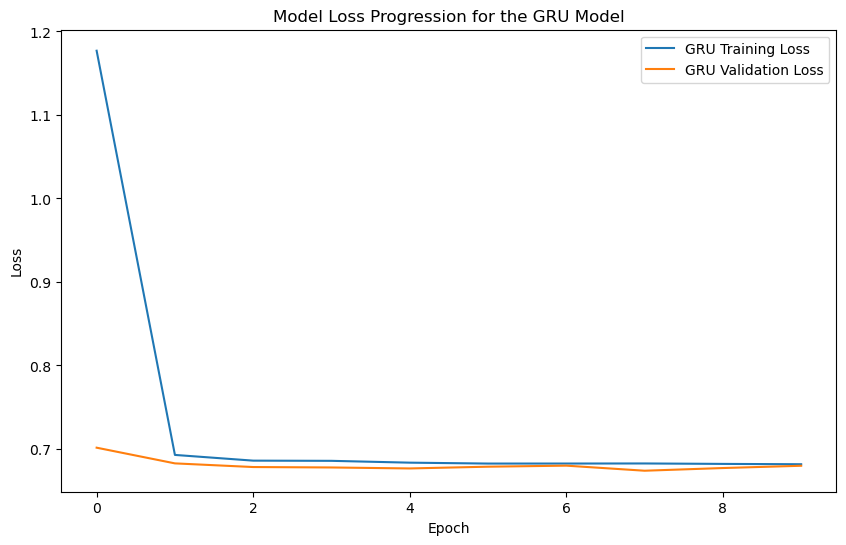

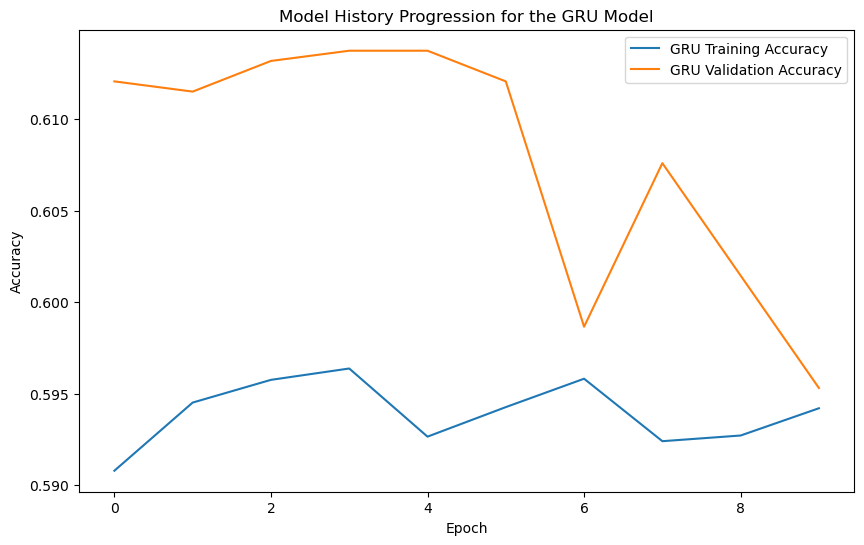

Epoch 1/10
504/504 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.5493 - loss: 4.1257 - val_accuracy: 0.5858 - val_loss: 2.0505
Epoch 2/10
504/504 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.5611 - loss: 1.8096 - val_accuracy: 0.6003 - val_loss: 1.2599
Epoch 3/10
504/504 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.5742 - loss: 1.1879 - val_accuracy: 0.6009 - val_loss: 0.9780
Epoch 4/10
504/504 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.5755 - loss: 0.9517 - val_accuracy: 0.5886 - val_loss: 0.8536
Epoch 5/10
504/504 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.5815 - loss: 0.8426 - val_accuracy: 0.6015 - val_loss: 0.7775
Epoch 6/10
504/504 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.5794 - loss: 0.7811 - val_accuracy: 0.6065 - val_loss: 0.7354
Epoch 7/10
504/504 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.5790 - loss: 0.7432 - val_accuracy: 0.5987 - val_loss: 0.7197
Epoch 8/10
504/504 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.5808 - loss: 0.7229 - val_acc

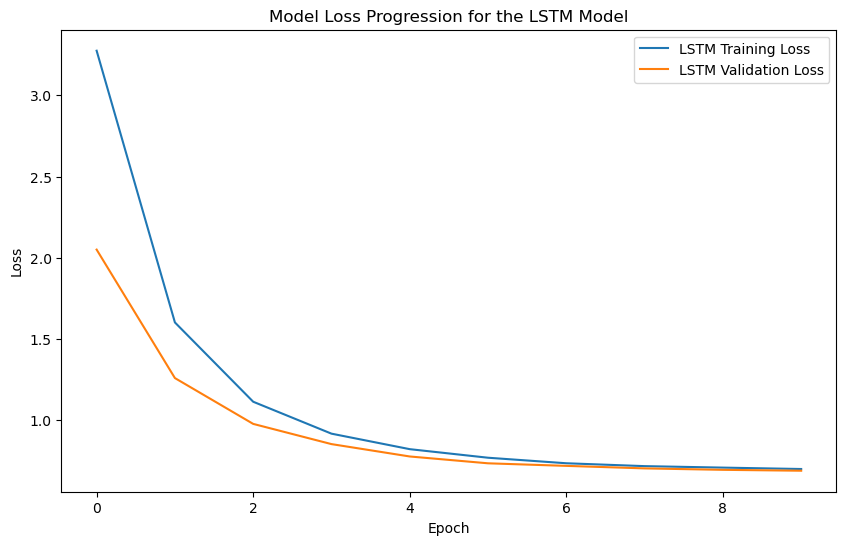

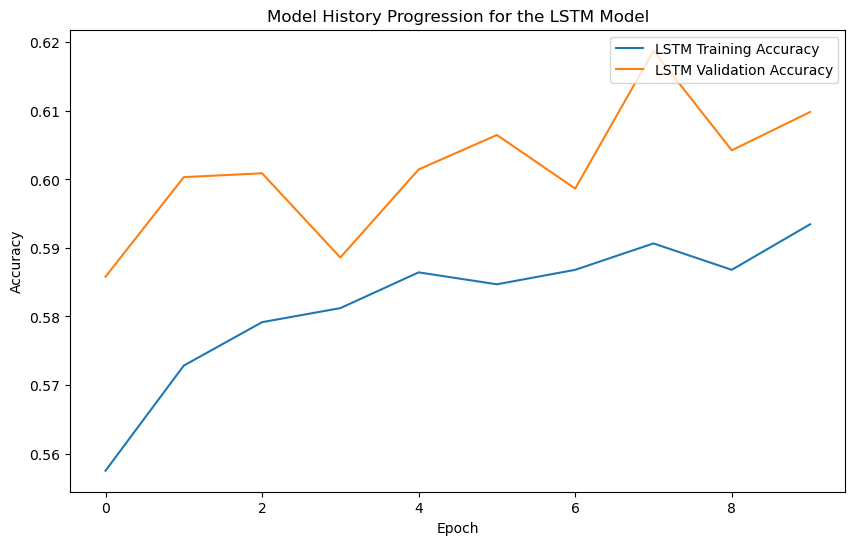

In [33]:
history = gru_model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.1)
plot_history(history, 'GRU')
history = lstm_model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.1)
plot_history(history, 'LSTM')

In [34]:
threshold = 0.5

In [35]:
#LSTM Model Results
y_val_pred_lstm = (lstm_model.predict(X_val) >= threshold).astype(int)
y_test_pred_lstm = (lstm_model.predict(fin_test_tensor) >= threshold).astype(int)

#F1 for validation
print("F1 Score for Validation", f1_score(y_val, y_val_pred_lstm))

#F1 for test set
print("F1 Score for Test", f1_score(fin_test_label_tensor, y_test_pred_lstm))

#precision for validation
print("Precision Score for Validation", precision_score(y_val, y_val_pred_lstm))

#precision for test set
print("Precision Score for Test", precision_score(fin_test_label_tensor, y_test_pred_lstm))

#recall for validation
print("Recall Score for Validation", recall_score(y_val, y_val_pred_lstm))

#recall for test set
print("Recall Score for Test", recall_score(fin_test_label_tensor, y_test_pred_lstm))

140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
F1 Score for Validation 0.6052919308987537
F1 Score for Test 0.6018614270941054
Precision Score for Validation 0.5909479077711358
Precision Score for Test 0.5694716242661448
Recall Score for Validation 0.6203496190049306
Recall Score for Test 0.6381578947368421


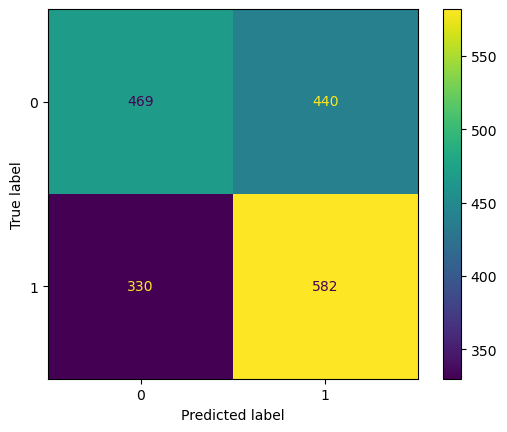

In [36]:
cm = confusion_matrix(fin_test_label_tensor, y_test_pred_lstm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

In [37]:
#GRU Model Results
y_val_pred_gru = (gru_model.predict(X_val) >= threshold).astype(int)
y_test_pred_gru = (gru_model.predict(fin_test_tensor) >= threshold).astype(int)

#F1 for validation
print("F1 Score for Validation", f1_score(y_val, y_val_pred_gru))

#F1 for test set
print("F1 Score for Test", f1_score(fin_test_label_tensor, y_test_pred_gru))

#precision for validation
print("Precision Score for Validation", precision_score(y_val, y_val_pred_gru))

#precision for test set
print("Precision Score for Test", precision_score(fin_test_label_tensor, y_test_pred_gru))

#recall for validation
print("Recall Score for Validation", recall_score(y_val, y_val_pred_gru))

#recall for test set
print("Recall Score for Test", recall_score(fin_test_label_tensor, y_test_pred_gru))

140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
F1 Score for Validation 0.537125597785049
F1 Score for Test 0.5482352941176472
Precision Score for Validation 0.6125143513203215
Precision Score for Test 0.5913705583756346
Recall Score for Validation 0.4782608695652174
Recall Score for Test 0.5109649122807017


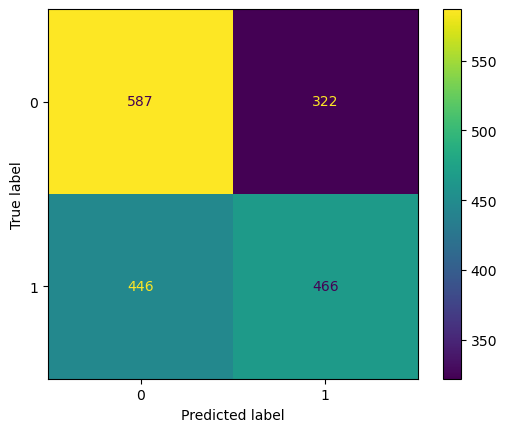

In [38]:
cm = confusion_matrix(fin_test_label_tensor, y_test_pred_gru)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

In [39]:
#Accuracy for GRU Model
gru_model.evaluate(fin_test_tensor, fin_test_label_tensor)

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5667 - loss: 0.6893


[0.6877670884132385, 0.5782536864280701]

In [40]:
#Accuracy for Test Set
lstm_model.evaluate(fin_test_tensor, fin_test_label_tensor)

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5596 - loss: 0.7121


[0.7073450684547424, 0.5771554112434387]

# Expected Profit Calculation

In [41]:
#dont bet on games with high moneylines
def calculate_profits_with_outcome(df, preds, bet_amount=100, ml_cutoff = -250):
    total_profit = 0
    count_bets = 0
    predicted_outcomes = preds
    outcomes = df.outcome
    home_moneylines = df.moneyLine
    opponent_moneylines = df.opponentMoneyLine

    for pred, outcome, home_ml, opp_ml in zip(predicted_outcomes, outcomes, home_moneylines, opponent_moneylines):
        if (pred == 0 and opp_ml >= ml_cutoff) or (pred == 1 and home_ml >= ml_cutoff):
            if pred == outcome:  # Prediction matches outcome
                if pred == 0:  # Opponent wins
                    if opp_ml > 0:
                        profit = bet_amount * (opp_ml / 100)
                    else:
                        profit = bet_amount / (-opp_ml / 100)
                    total_profit += profit
                else:  # Home team wins
                    if home_ml > 0:
                        profit = bet_amount * (home_ml / 100)
                    else:
                        profit = bet_amount / (-home_ml / 100)
                    total_profit += profit
            else:  # Prediction does not match outcome
                total_profit -= bet_amount

    return total_profit

def calculate_profits_with_tensor_data(preds, outcomes, money_lines, bet_amount=100, ml_cutoff=-250):
    """
    Calculate the total profits based on predictions, actual outcomes, and money line values.
    
    :param preds: 1D array of predicted outcomes (0 or 1).
    :param outcomes: 1D array of actual outcomes.
    :param money_lines: 1D array of money line values corresponding to each game.
    :param bet_amount: The fixed amount to bet on each game.
    :param ml_cutoff: The cutoff for money line to consider the bet.
    
    :return: Total profit from betting based on the model's predictions.
    """
    total_profit = 0
    count_bets = 0

    for pred, outcome, ml in zip(preds, outcomes, money_lines):
        # Determine which money line to consider based on the prediction
        effective_ml = ml if pred == 1 else -ml  # Assuming negative money lines imply betting on the opponent
        
        # Only bet if the effective money line is greater than or equal to the cutoff
        if effective_ml >= ml_cutoff:
            if pred == outcome:  # Prediction matches the actual outcome
                profit = bet_amount * (effective_ml / 100) if effective_ml > 0 else bet_amount / (-effective_ml / 100)
                total_profit += profit
            else:  # Prediction does not match the outcome
                total_profit -= bet_amount
            count_bets += 1

    return total_profit, count_bets


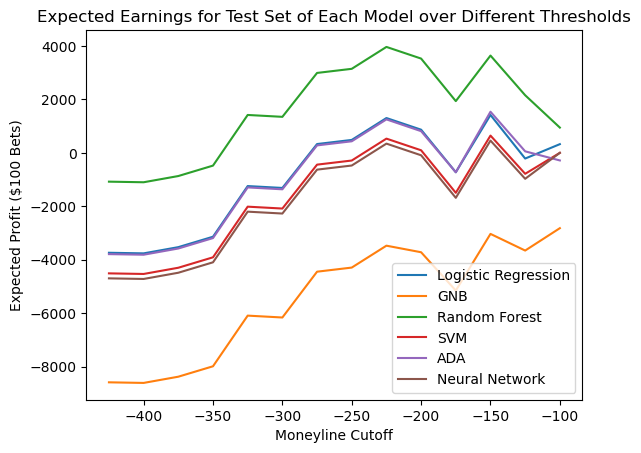

In [42]:
possible_ml_thresholds = np.arange(-100, -450, -25)
test_predictions = {'Logistic Regression' : lr_test_preds, 'GNB' : gnb_test_preds,
                    'Random Forest' : rf_test_preds, 'SVM' : svm_test_preds,
                    'ADA' : ada_test_preds, 'Neural Network' : nn_test_preds}
model_profits = {}

for model in test_predictions:
    profits = []
    for i in possible_ml_thresholds:
        curr_profit = calculate_profits_with_outcome(test, test_predictions[model], 100, i)
        profits.append(curr_profit)
    model_profits[model] = profits.copy()

model_profits = pd.DataFrame(model_profits)
#model_profits['Threshold'] = possible_ml_thresholds
for model in model_profits.columns:
    plt.plot(possible_ml_thresholds, model_profits[model], label = model)
plt.legend()
plt.xlabel('Moneyline Cutoff')
plt.ylabel('Expected Profit ($100 Bets)')
plt.title('Expected Earnings for Test Set of Each Model over Different Thresholds');

In [43]:
calculate_profits_with_outcome(test, lr_test_preds, 100, -150)

1416.8334455815761

In [44]:
calculate_profits_with_outcome(test, gnb_test_preds, 100, -150)

-3034.670873576415

In [45]:
calculate_profits_with_outcome(test, rf_test_preds, 100, -150)

3641.0717393551

In [46]:
calculate_profits_with_outcome(test, svm_test_preds, 100, -150)

645.8048365094859

In [47]:
calculate_profits_with_outcome(test, ada_test_preds, 100, -150)

1538.3519271000564

In [48]:
calculate_profits_with_outcome(test, nn_test_preds, 100, -150)

458.8483147703563

In [49]:
total_profit, count_bets = calculate_profits_with_tensor_data(y_test_pred_gru, fin_test_label_tensor, test_money_line_tensor, bet_amount=100, ml_cutoff=-250)
print("Total profit from GRU Model", total_profit)

Total profit from GRU Model 2104.204310730345


In [50]:
total_profit, count_bets = calculate_profits_with_tensor_data(y_test_pred_lstm, fin_test_label_tensor, test_money_line_tensor, bet_amount=100, ml_cutoff=-250)
print("Total profits from LSTM Model", total_profit)

Total profits from LSTM Model -2635.67532375419
